# MovieLens Offline Benchmark (1M/100K Auto-Detect)

This notebook compares three recommenders on implicit feedback (`rating >= 4`):

1. Item-item collaborative filtering
2. Matrix factorization (truncated SVD)
3. Deep pointwise ranker with DCNv2-style feature crossing

Evaluation uses per-user temporal holdout (last 10% interactions) and reports **MRR** + **Precision@10**.

Speed guards included:
- Guard 1: top-K neighbors for item-item CF
- Guard 2: sparse blocked similarity computation for item-item CF
- Guard 3: capped latent dimension for MF
- Deep-model training guard: epoch cap + early stopping
- Deep-model feature pruning: drop very-low-support item features


In [1]:
from pathlib import Path
import random
import zipfile

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, vstack
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Works when launched from repo root or from inside recsys/.
if (Path.cwd() / "recsys").exists():
    RECSYS_DIR = Path.cwd() / "recsys"
else:
    RECSYS_DIR = Path.cwd()

DATA_DIR = RECSYS_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

ml1m_dir = DATA_DIR / "ml-1m"
ml1m_zip = DATA_DIR / "ml-1m.zip"
ml100k_dir = DATA_DIR / "ml-100k"
ml100k_zip = DATA_DIR / "ml-100k.zip"

if not ml1m_dir.exists() and ml1m_zip.exists():
    with zipfile.ZipFile(ml1m_zip, "r") as zf:
        zf.extractall(DATA_DIR)

if not ml100k_dir.exists() and ml100k_zip.exists():
    with zipfile.ZipFile(ml100k_zip, "r") as zf:
        zf.extractall(DATA_DIR)

if (ml1m_dir / "ratings.dat").exists():
    DATASET_NAME = "ml-1m"
    RATINGS_PATH = ml1m_dir / "ratings.dat"
    MOVIES_PATH = ml1m_dir / "movies.dat"
elif (ml100k_dir / "u.data").exists():
    DATASET_NAME = "ml-100k"
    RATINGS_PATH = ml100k_dir / "u.data"
    MOVIES_PATH = ml100k_dir / "u.item"
else:
    raise FileNotFoundError(
        "No supported MovieLens dataset found. Expected ml-1m or ml-100k under recsys/data."
    )

print(f"Using dataset: {DATASET_NAME}")
print(f"Ratings file: {RATINGS_PATH}")


Using dataset: ml-1m
Ratings file: /Users/cow/Development/machine-learning-dump/recsys/data/ml-1m/ratings.dat


In [3]:
if DATASET_NAME == "ml-1m":
    ratings = pd.read_csv(
        RATINGS_PATH,
        sep="::",
        names=["user_id", "item_id", "rating", "timestamp"],
        engine="python",
    )
    movies_raw = pd.read_csv(
        MOVIES_PATH,
        sep="::",
        names=["item_id", "title", "genres"],
        encoding="latin-1",
        engine="python",
    )
else:
    ratings = pd.read_csv(
        RATINGS_PATH,
        sep="\t",
        names=["user_id", "item_id", "rating", "timestamp"],
        engine="python",
    )

    genre_cols_100k = [
        "unknown", "Action", "Adventure", "Animation", "Childrens", "Comedy",
        "Crime", "Documentary", "Drama", "Fantasy", "FilmNoir", "Horror",
        "Musical", "Mystery", "Romance", "SciFi", "Thriller", "War", "Western",
    ]
    item_columns = ["item_id", "title", "release_date", "video_release_date", "imdb_url", *genre_cols_100k]
    movies_raw = pd.read_csv(
        MOVIES_PATH,
        sep="|",
        names=item_columns,
        encoding="latin-1",
        engine="python",
    )

ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

POSITIVE_THRESHOLD = 4
interactions = (
    ratings[ratings["rating"] >= POSITIVE_THRESHOLD]
    .sort_values("timestamp")
    .drop_duplicates(["user_id", "item_id"], keep="last")
    .reset_index(drop=True)
)

print(f"All rows: {len(ratings):,}")
print(f"Positive implicit interactions (rating >= {POSITIVE_THRESHOLD}): {len(interactions):,}")
print(
    f"Users: {interactions['user_id'].nunique()}, Items: {interactions['item_id'].nunique()}, "
    f"Date range: {interactions['datetime'].min()} -> {interactions['datetime'].max()}"
)
interactions.head()


All rows: 1,000,209
Positive implicit interactions (rating >= 4): 575,281
Users: 6038, Items: 3533, Date range: 2000-04-25 23:05:32 -> 2003-02-28 17:49:50


,user_id,item_id,rating,timestamp,datetime
0,6040,858,4,956703932,2000-04-25 23:05:32
1,6040,2384,4,956703954,2000-04-25 23:05:54
2,6040,593,5,956703954,2000-04-25 23:05:54
3,6040,1961,4,956703977,2000-04-25 23:06:17
4,6040,2019,5,956703977,2000-04-25 23:06:17


## Data Exploration: Dataset Shape, Sparsity, and Interaction Distribution

These cells are intentionally near the top so you can inspect data quality before training models.


In [4]:
# High-level EDA summary for explicit ratings and implicit positives.
user_pos_counts = interactions.groupby("user_id").size()
item_pos_counts = interactions.groupby("item_id").size()

num_user_pos = interactions["user_id"].nunique()
num_item_pos = interactions["item_id"].nunique()
density = len(interactions) / float(max(num_user_pos * num_item_pos, 1))
sparsity = 1.0 - density

eda_summary = pd.DataFrame([
    {"metric": "dataset", "value": DATASET_NAME},
    {"metric": "explicit_rows", "value": int(len(ratings))},
    {"metric": "implicit_positive_rows", "value": int(len(interactions))},
    {"metric": "num_users_positive", "value": int(num_user_pos)},
    {"metric": "num_items_positive", "value": int(num_item_pos)},
    {"metric": "implicit_density", "value": float(density)},
    {"metric": "implicit_sparsity", "value": float(sparsity)},
    {"metric": "median_pos_per_user", "value": float(user_pos_counts.median())},
    {"metric": "median_pos_per_item", "value": float(item_pos_counts.median())},
]).set_index("metric")

eda_summary


,value
metric,
dataset,ml-1m
explicit_rows,1000209
implicit_positive_rows,575281
num_users_positive,6038
num_items_positive,3533
implicit_density,0.026968
implicit_sparsity,0.973032
median_pos_per_user,58.0
median_pos_per_item,49.0


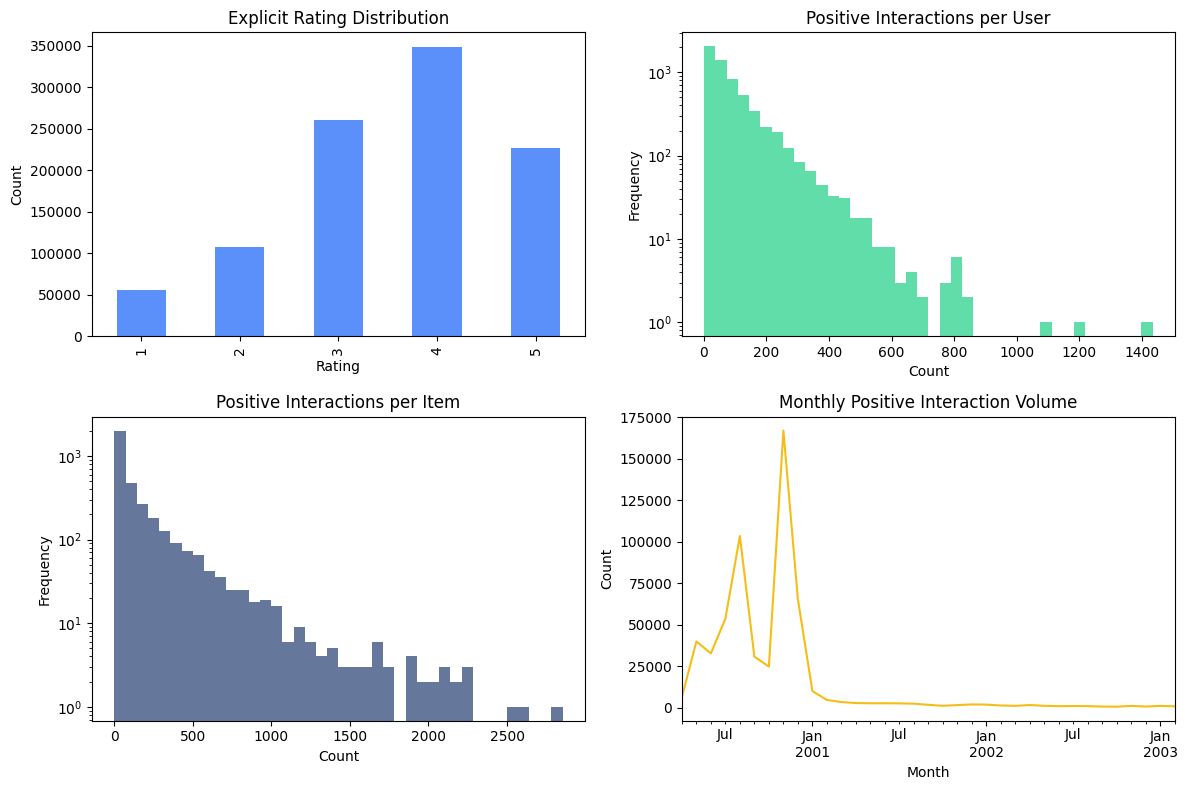

In [5]:
# Visualize distribution skew and temporal volume.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="#5B8FF9")
axes[0, 0].set_title("Explicit Rating Distribution")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

user_pos_counts.plot(kind="hist", bins=40, ax=axes[0, 1], color="#61DDAA")
axes[0, 1].set_title("Positive Interactions per User")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_yscale("log")

item_pos_counts.plot(kind="hist", bins=40, ax=axes[1, 0], color="#65789B")
axes[1, 0].set_title("Positive Interactions per Item")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_yscale("log")

monthly_positive = interactions.set_index("datetime").resample("ME").size()
monthly_positive.plot(ax=axes[1, 1], color="#F6BD16")
axes[1, 1].set_title("Monthly Positive Interaction Volume")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [6]:
def temporal_user_holdout(df, eval_ratio=0.1, user_col="user_id"):
    train_parts = []
    eval_parts = []

    for _, group in df.sort_values("timestamp").groupby(user_col):
        n = len(group)
        if n < 2:
            train_parts.append(group)
            continue

        n_eval = max(1, int(np.ceil(n * eval_ratio)))
        n_eval = min(n_eval, n - 1)

        train_parts.append(group.iloc[:-n_eval])
        eval_parts.append(group.iloc[-n_eval:])

    train_df = pd.concat(train_parts).sort_values("timestamp").reset_index(drop=True)
    eval_df = pd.concat(eval_parts).sort_values("timestamp").reset_index(drop=True)
    return train_df, eval_df

train_df, eval_df = temporal_user_holdout(interactions, eval_ratio=0.1, user_col="user_id")

user_ids = np.sort(train_df["user_id"].unique())
item_ids = np.sort(train_df["item_id"].unique())
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {it: i for i, it in enumerate(item_ids)}

train_df = train_df.assign(
    u=train_df["user_id"].map(user_to_idx),
    i=train_df["item_id"].map(item_to_idx),
)

eval_df = eval_df[
    eval_df["user_id"].isin(user_to_idx) & eval_df["item_id"].isin(item_to_idx)
].copy()
eval_df = eval_df.assign(
    u=eval_df["user_id"].map(user_to_idx),
    i=eval_df["item_id"].map(item_to_idx),
)

num_users = len(user_ids)
num_items = len(item_ids)

train_matrix = csr_matrix(
    (
        np.ones(len(train_df), dtype=np.float32),
        (train_df["u"].to_numpy(), train_df["i"].to_numpy()),
    ),
    shape=(num_users, num_items),
)

train_user_items = train_df.groupby("u")["i"].apply(lambda s: set(s.astype(int).tolist())).to_dict()
eval_user_items = eval_df.groupby("u")["i"].apply(lambda s: set(s.astype(int).tolist())).to_dict()
eval_users = sorted(u for u in eval_user_items if eval_user_items[u] and train_user_items.get(u))

print(f"Train interactions: {len(train_df):,}")
print(f"Eval interactions: {len(eval_df):,}")
print(f"Users in eval: {len(eval_users):,}")
print(f"Matrix shape: {train_matrix.shape}")


Train interactions: 515,069
Eval interactions: 60,155
Users in eval: 6,036
Matrix shape: (6038, 3486)


In [7]:
# Split diagnostics: how much history each user has for training vs evaluation.
train_counts = train_df.groupby("u").size()
eval_counts = eval_df.groupby("u").size()

split_summary = pd.DataFrame([
    {"metric": "users_with_eval", "value": int(len(eval_counts))},
    {"metric": "users_with_<5_train_interactions", "value": int((train_counts < 5).sum())},
    {"metric": "users_with_<10_train_interactions", "value": int((train_counts < 10).sum())},
    {"metric": "median_train_interactions_per_user", "value": float(train_counts.median())},
    {"metric": "median_eval_interactions_per_user", "value": float(eval_counts.median())},
]).set_index("metric")

split_summary


,value
metric,
users_with_eval,6036.0
users_with_<5_train_interactions,10.0
users_with_<10_train_interactions,166.0
median_train_interactions_per_user,52.0
median_eval_interactions_per_user,6.0


In [8]:
def evaluate_model(score_fn, eval_users, eval_user_items, train_user_items, num_items, k=10):
    precision_scores = []
    rr_scores = []

    for u in eval_users:
        positives = eval_user_items.get(u, set())
        if not positives:
            continue

        seen = train_user_items.get(u, set())
        scores = score_fn(u).astype(np.float64, copy=True)
        if seen:
            scores[list(seen)] = -np.inf

        ranked_items = np.argsort(-scores)
        top_k = ranked_items[:k]
        precision_scores.append(len(set(top_k) & positives) / float(k))

        rank_positions = np.empty(num_items, dtype=np.int32)
        rank_positions[ranked_items] = np.arange(1, num_items + 1, dtype=np.int32)
        best_rank = min(rank_positions[list(positives)])
        rr_scores.append(1.0 / float(best_rank))

    return {
        "MRR": float(np.mean(rr_scores)),
        f"Precision@{k}": float(np.mean(precision_scores)),
        "n_eval_users": int(len(rr_scores)),
    }


## Guard 1 + Guard 2: Item-Item CF with Top-K + Sparse Blocked Similarity

- **Guard 1** (`ITEMCF_TOPK`) keeps only the strongest neighbors per item.
- **Guard 2** (`ITEMCF_BLOCK_SIZE`) computes cosine similarities in sparse blocks instead of one dense full matrix.


In [9]:
def l2_normalize_rows(mat_csr):
    mat_csr = mat_csr.tocsr().astype(np.float32)
    row_sq_sum = np.asarray(mat_csr.multiply(mat_csr).sum(axis=1)).reshape(-1)
    row_norm = np.sqrt(np.maximum(row_sq_sum, 1e-12))
    inv_norm = 1.0 / row_norm
    return mat_csr.multiply(inv_norm[:, None]).tocsr()


def keep_topk_per_row(sim_block, row_offset, top_k):
    sim_block = sim_block.tocsr()
    rows = []
    cols = []
    vals = []

    for local_r in range(sim_block.shape[0]):
        global_r = row_offset + local_r
        start = sim_block.indptr[local_r]
        end = sim_block.indptr[local_r + 1]

        c = sim_block.indices[start:end]
        v = sim_block.data[start:end]

        # Remove self-similarity and keep strictly positive similarities.
        keep_mask = (c != global_r) & (v > 0)
        c = c[keep_mask]
        v = v[keep_mask]

        if len(v) == 0:
            continue

        if len(v) > top_k:
            top_idx = np.argpartition(v, -top_k)[-top_k:]
            c = c[top_idx]
            v = v[top_idx]

        # Sort retained neighbors for deterministic behavior.
        order = np.argsort(-v)
        c = c[order]
        v = v[order]

        rows.append(np.full(len(c), global_r, dtype=np.int32))
        cols.append(c.astype(np.int32, copy=False))
        vals.append(v.astype(np.float32, copy=False))

    if not rows:
        return csr_matrix((sim_block.shape[0], sim_block.shape[1]), dtype=np.float32)

    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    vals = np.concatenate(vals)
    return csr_matrix((vals, (rows - row_offset, cols)), shape=sim_block.shape, dtype=np.float32)


def build_itemcf_similarity_topk_blocked(train_matrix, top_k=200, block_size=256):
    # item-user matrix, row-normalized for cosine similarity via sparse dot product.
    item_user = l2_normalize_rows(train_matrix.T.tocsr())
    num_items_local = item_user.shape[0]

    blocks = []
    for start in range(0, num_items_local, block_size):
        end = min(start + block_size, num_items_local)

        sim_block = item_user[start:end] @ item_user.T
        sim_block = keep_topk_per_row(sim_block, row_offset=start, top_k=top_k)
        blocks.append(sim_block)

    sim_topk = vstack(blocks, format="csr")
    sim_topk.eliminate_zeros()
    return sim_topk


ITEMCF_TOPK = 200 if DATASET_NAME == "ml-1m" else 100
ITEMCF_BLOCK_SIZE = 256 if DATASET_NAME == "ml-1m" else 128

item_similarity_topk = build_itemcf_similarity_topk_blocked(
    train_matrix=train_matrix,
    top_k=ITEMCF_TOPK,
    block_size=ITEMCF_BLOCK_SIZE,
)

itemcf_score_cache = {}

def itemcf_score_fn(u):
    cached = itemcf_score_cache.get(int(u))
    if cached is not None:
        return cached
    scores = train_matrix.getrow(u) @ item_similarity_topk
    arr = scores.toarray().ravel().astype(np.float32, copy=False)
    itemcf_score_cache[int(u)] = arr
    return arr

itemcf_metrics = evaluate_model(
    score_fn=itemcf_score_fn,
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    k=10,
)

print(f"ItemCF similarity nnz: {item_similarity_topk.nnz:,}")
print(itemcf_metrics)


ItemCF similarity nnz: 685,575
{'MRR': 0.13999356582217223, 'Precision@10': 0.04594102054340623, 'n_eval_users': 6036}


## Guard 3: Matrix Factorization with Capped Latent Dimension

`MF_LATENT_DIM_CAP` intentionally limits factor size so SVD stays fast and stable on larger datasets.


In [10]:
MF_LATENT_DIM_CAP = 24 if DATASET_NAME == "ml-1m" else 32
latent_dim = min(MF_LATENT_DIM_CAP, min(train_matrix.shape) - 1)

user_factors, singular_vals, item_factors_t = svds(train_matrix.astype(np.float32), k=latent_dim)

order = np.argsort(-singular_vals)
user_factors = user_factors[:, order]
singular_vals = singular_vals[order]
item_factors_t = item_factors_t[order, :]

mf_scores = np.asarray((user_factors * singular_vals) @ item_factors_t, dtype=np.float32)

mf_metrics = evaluate_model(
    score_fn=lambda u: mf_scores[u],
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    k=10,
)

print(f"MF latent_dim={latent_dim}")
print(mf_metrics)


MF latent_dim=24
{'MRR': 0.15529693403118597, 'Precision@10': 0.05147448641484426, 'n_eval_users': 6036}


## Deep Model: DCNv2 + Feature Pruning + Early Stopping

Deep-model guards documented here:
- **Feature pruning**: drop item side features with very low support to reduce noise/compute.
- **Epoch limit**: hard cap on training epochs (`MAX_EPOCHS`).
- **Early stopping**: stop when validation MRR no longer improves (`EARLY_STOP_PATIENCE`).

Feature pruning strategy in this notebook:
- Build genre one-hot + normalized year.
- Keep year always.
- For binary genre features, keep only those active in at least `FEATURE_PRUNING_MIN_SUPPORT` items.


In [11]:
# Build item side features then prune low-support binary features.
if DATASET_NAME == "ml-1m":
    movies_meta = movies_raw.copy()
    movies_meta["release_year"] = pd.to_numeric(
        movies_meta["title"].str.extract(r"\((\d{4})\)\s*$")[0],
        errors="coerce",
    )

    genre_vocab = sorted({g for gs in movies_meta["genres"].fillna("") for g in gs.split("|") if g})
    binary_feature_names = genre_vocab
    genre_to_idx = {g: i for i, g in enumerate(genre_vocab)}

    year_median = float(movies_meta["release_year"].median())
    movies_meta["release_year"] = movies_meta["release_year"].fillna(year_median)
    year_mean = float(movies_meta["release_year"].mean())
    year_std = float(movies_meta["release_year"].std())
    if year_std < 1e-6:
        year_std = 1.0
    movies_meta["year_norm"] = (movies_meta["release_year"] - year_mean) / year_std

    raw_side = np.zeros((num_items, len(binary_feature_names) + 1), dtype=np.float32)
    for row in movies_meta.itertuples(index=False):
        i_idx = item_to_idx.get(int(row.item_id))
        if i_idx is None:
            continue

        for g in str(row.genres).split("|"):
            g_idx = genre_to_idx.get(g)
            if g_idx is not None:
                raw_side[i_idx, g_idx] = 1.0

        raw_side[i_idx, -1] = float(row.year_norm)

else:
    movies_meta = movies_raw.copy()
    binary_feature_names = [
        "unknown", "Action", "Adventure", "Animation", "Childrens", "Comedy",
        "Crime", "Documentary", "Drama", "Fantasy", "FilmNoir", "Horror",
        "Musical", "Mystery", "Romance", "SciFi", "Thriller", "War", "Western",
    ]

    movies_meta["release_year"] = pd.to_numeric(
        movies_meta["release_date"].str.extract(r"(\d{4})")[0],
        errors="coerce",
    )

    year_median = float(movies_meta["release_year"].median())
    movies_meta["release_year"] = movies_meta["release_year"].fillna(year_median)
    year_mean = float(movies_meta["release_year"].mean())
    year_std = float(movies_meta["release_year"].std())
    if year_std < 1e-6:
        year_std = 1.0
    movies_meta["year_norm"] = (movies_meta["release_year"] - year_mean) / year_std

    raw_side = np.zeros((num_items, len(binary_feature_names) + 1), dtype=np.float32)
    for row in movies_meta.itertuples(index=False):
        i_idx = item_to_idx.get(int(row.item_id))
        if i_idx is None:
            continue

        genre_values = [float(getattr(row, c)) for c in binary_feature_names]
        raw_side[i_idx, :len(binary_feature_names)] = np.array(genre_values, dtype=np.float32)
        raw_side[i_idx, -1] = float(row.year_norm)

FEATURE_PRUNING_MIN_SUPPORT = 25 if DATASET_NAME == "ml-1m" else 5
binary_support = raw_side[:, :-1].sum(axis=0)
keep_binary_mask = binary_support >= FEATURE_PRUNING_MIN_SUPPORT

if keep_binary_mask.sum() == 0:
    keep_binary_mask[:] = True

kept_binary_names = [name for name, keep in zip(binary_feature_names, keep_binary_mask) if keep]
item_side_matrix = np.concatenate([raw_side[:, :-1][:, keep_binary_mask], raw_side[:, -1:]], axis=1).astype(np.float32)
item_side_dim = item_side_matrix.shape[1]

print(f"Raw side features: {raw_side.shape[1]} (binary={len(binary_feature_names)} + year)")
print(f"Pruned side features: {item_side_dim} (kept binary={len(kept_binary_names)} + year)")
print(f"Dropped binary features: {len(binary_feature_names) - len(kept_binary_names)}")

item_popularity = np.asarray(train_matrix.sum(axis=0)).reshape(-1).astype(np.float64)
item_popularity = np.power(item_popularity + 1e-6, 0.75)
item_popularity /= item_popularity.sum()

# Deep model uses a train/validation split from train_df for early stopping.
EARLY_STOP_VAL_RATIO = 0.05
deep_train_df, deep_val_df = temporal_user_holdout(train_df, eval_ratio=EARLY_STOP_VAL_RATIO, user_col="u")

deep_train_user_items = deep_train_df.groupby("u")["i"].apply(lambda s: set(s.astype(int).tolist())).to_dict()
deep_val_user_items = deep_val_df.groupby("u")["i"].apply(lambda s: set(s.astype(int).tolist())).to_dict()
deep_val_users = sorted(u for u in deep_val_user_items if deep_val_user_items[u] and deep_train_user_items.get(u))

deep_train_pairs = deep_train_df[["u", "i"]].to_numpy(dtype=np.int64)

if DATASET_NAME == "ml-1m":
    NEGATIVES_PER_POSITIVE = 6
    POSITIVE_BATCH_SIZE = 1024
    EMB_DIM = 64
    SIDE_HIDDEN_DIM = 32
    MAX_EPOCHS = 8
    EARLY_STOP_PATIENCE = 2
else:
    NEGATIVES_PER_POSITIVE = 16
    POSITIVE_BATCH_SIZE = 512
    EMB_DIM = 48
    SIDE_HIDDEN_DIM = 24
    MAX_EPOCHS = 10
    EARLY_STOP_PATIENCE = 3

MIN_EPOCHS_BEFORE_STOP = 2
NEGATIVE_SAMPLING_MIX = {"random": 0.5, "popularity": 0.3, "inbatch": 0.2}
DCN_CROSS_LAYERS = 3
DEEP_HIDDEN_DIMS = (128, 64)

print(f"Deep train pairs: {len(deep_train_pairs):,}, deep val interactions: {len(deep_val_df):,}")
print(f"Deep validation users: {len(deep_val_users):,}")
print(
    f"Deep config -> negatives/positive: {NEGATIVES_PER_POSITIVE}, max_epochs: {MAX_EPOCHS}, "
    f"patience: {EARLY_STOP_PATIENCE}, batch: {POSITIVE_BATCH_SIZE}"
)


Raw side features: 19 (binary=18 + year)
Pruned side features: 19 (kept binary=18 + year)
Dropped binary features: 0
Deep train pairs: 486,531, deep val interactions: 28,538
Deep validation users: 6,035
Deep config -> negatives/positive: 6, max_epochs: 8, patience: 2, batch: 1024


In [12]:
class CrossLayerV2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.proj = nn.Linear(input_dim, input_dim, bias=True)

    def forward(self, x0, xl):
        return x0 * self.proj(xl) + xl


class CrossNetworkV2(nn.Module):
    def __init__(self, input_dim, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([CrossLayerV2(input_dim) for _ in range(num_layers)])

    def forward(self, x):
        x0 = x
        xl = x
        for layer in self.layers:
            xl = layer(x0, xl)
        return xl


class PointwiseDCNv2WithItemFeatures(nn.Module):
    def __init__(
        self,
        num_users,
        num_items,
        item_side_dim,
        emb_dim=64,
        side_hidden_dim=32,
        cross_layers=3,
        deep_hidden_dims=(128, 64),
        dropout=0.15,
    ):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.side_encoder = nn.Sequential(
            nn.Linear(item_side_dim, side_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        stacked_dim = emb_dim + emb_dim + side_hidden_dim
        self.cross_net = CrossNetworkV2(stacked_dim, cross_layers)

        deep_layers = []
        in_dim = stacked_dim
        for h in deep_hidden_dims:
            deep_layers.append(nn.Linear(in_dim, h))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(dropout))
            in_dim = h
        self.deep_tower = nn.Sequential(*deep_layers)

        self.out = nn.Linear(stacked_dim + in_dim, 1)

    def forward(self, user_ids, item_ids, item_side_features):
        user_vec = self.user_emb(user_ids)
        item_vec = self.item_emb(item_ids)
        side_vec = self.side_encoder(item_side_features)
        x = torch.cat([user_vec, item_vec, side_vec], dim=-1)

        cross_out = self.cross_net(x)
        deep_out = self.deep_tower(x)
        merged = torch.cat([cross_out, deep_out], dim=-1)
        return self.out(merged).squeeze(-1)


def sample_negative_item(seen_items, batch_items_np, rng, mix_probs):
    sources = ("random", "popularity", "inbatch")

    for _ in range(80):
        source = rng.choice(sources, p=mix_probs)

        if source == "random":
            j = int(rng.integers(0, num_items))
        elif source == "popularity":
            j = int(rng.choice(num_items, p=item_popularity))
        else:
            j = int(batch_items_np[int(rng.integers(0, len(batch_items_np)))])

        if j not in seen_items:
            return j

    for _ in range(200):
        j = int(rng.integers(0, num_items))
        if j not in seen_items:
            return j

    return int(rng.integers(0, num_items))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
item_side_tensor = torch.tensor(item_side_matrix, dtype=torch.float32, device=device)
all_item_tensor = torch.arange(num_items, dtype=torch.long, device=device)

positive_dataset = TensorDataset(
    torch.from_numpy(deep_train_pairs[:, 0]),
    torch.from_numpy(deep_train_pairs[:, 1]),
)

pointwise_model = PointwiseDCNv2WithItemFeatures(
    num_users=num_users,
    num_items=num_items,
    item_side_dim=item_side_dim,
    emb_dim=EMB_DIM,
    side_hidden_dim=SIDE_HIDDEN_DIM,
    cross_layers=DCN_CROSS_LAYERS,
    deep_hidden_dims=DEEP_HIDDEN_DIMS,
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([NEGATIVES_PER_POSITIVE], dtype=torch.float32, device=device)
)
optimizer = torch.optim.Adam(pointwise_model.parameters(), lr=1e-3, weight_decay=1e-6)

mix_probs = [
    NEGATIVE_SAMPLING_MIX["random"],
    NEGATIVE_SAMPLING_MIX["popularity"],
    NEGATIVE_SAMPLING_MIX["inbatch"],
]

best_state = None
best_epoch = 0
best_val_mrr = -1.0
bad_epochs = 0
training_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_loader = DataLoader(
        positive_dataset,
        batch_size=POSITIVE_BATCH_SIZE,
        shuffle=True,
    )

    pointwise_model.train()
    total_loss = 0.0
    total_examples = 0
    epoch_rng = np.random.default_rng(SEED + epoch)

    for batch_users, batch_items in epoch_loader:
        batch_users_np = batch_users.numpy().astype(np.int64, copy=False)
        batch_items_np = batch_items.numpy().astype(np.int64, copy=False)

        n_pos = len(batch_users_np)
        ex_n = n_pos * (NEGATIVES_PER_POSITIVE + 1)

        ex_users = np.empty(ex_n, dtype=np.int64)
        ex_items = np.empty(ex_n, dtype=np.int64)
        ex_labels = np.empty(ex_n, dtype=np.float32)

        cursor = 0
        for row_idx in range(n_pos):
            u = int(batch_users_np[row_idx])
            i = int(batch_items_np[row_idx])
            seen = deep_train_user_items[u]

            ex_users[cursor] = u
            ex_items[cursor] = i
            ex_labels[cursor] = 1.0
            cursor += 1

            for _ in range(NEGATIVES_PER_POSITIVE):
                j = sample_negative_item(seen, batch_items_np, epoch_rng, mix_probs)
                ex_users[cursor] = u
                ex_items[cursor] = j
                ex_labels[cursor] = 0.0
                cursor += 1

        ex_users_t = torch.from_numpy(ex_users).to(device, non_blocking=True)
        ex_items_t = torch.from_numpy(ex_items).to(device, non_blocking=True)
        ex_labels_t = torch.from_numpy(ex_labels).to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = pointwise_model(ex_users_t, ex_items_t, item_side_tensor[ex_items_t])
        loss = criterion(logits, ex_labels_t)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * ex_users_t.size(0)
        total_examples += ex_users_t.size(0)

    avg_loss = total_loss / max(total_examples, 1)

    @torch.no_grad()
    def val_score_fn(u):
        pointwise_model.eval()
        user_tensor = torch.full((num_items,), u, dtype=torch.long, device=device)
        logits = pointwise_model(user_tensor, all_item_tensor, item_side_tensor)
        return logits.detach().cpu().numpy()

    val_metrics = evaluate_model(
        score_fn=val_score_fn,
        eval_users=deep_val_users,
        eval_user_items=deep_val_user_items,
        train_user_items=deep_train_user_items,
        num_items=num_items,
        k=10,
    )
    val_mrr = val_metrics["MRR"]

    improved = val_mrr > best_val_mrr + 1e-6
    if improved:
        best_val_mrr = val_mrr
        best_epoch = epoch
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in pointwise_model.state_dict().items()}
    else:
        bad_epochs += 1

    training_history.append({
        "epoch": epoch,
        "train_loss": float(avg_loss),
        "val_mrr": float(val_mrr),
        "val_precision@10": float(val_metrics["Precision@10"]),
        "improved": bool(improved),
    })

    print(
        f"Epoch {epoch}/{MAX_EPOCHS} | loss={avg_loss:.4f} | val_mrr={val_mrr:.4f} | "
        f"val_p10={val_metrics['Precision@10']:.4f} | improved={improved}"
    )

    # Early stop guard after minimum warm-up epochs.
    if epoch >= MIN_EPOCHS_BEFORE_STOP and bad_epochs >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is not None:
    pointwise_model.load_state_dict(best_state)

print(f"Best deep model epoch: {best_epoch}, best validation MRR: {best_val_mrr:.4f}")
training_history_df = pd.DataFrame(training_history)
training_history_df


Epoch 1/8 | loss=1.0387 | val_mrr=0.0606 | val_p10=0.0166 | improved=True
Epoch 2/8 | loss=0.9345 | val_mrr=0.0660 | val_p10=0.0173 | improved=True
Epoch 3/8 | loss=0.8839 | val_mrr=0.0682 | val_p10=0.0183 | improved=True
Epoch 4/8 | loss=0.8517 | val_mrr=0.0721 | val_p10=0.0190 | improved=True
Epoch 5/8 | loss=0.8255 | val_mrr=0.0738 | val_p10=0.0189 | improved=True
Epoch 6/8 | loss=0.8029 | val_mrr=0.0743 | val_p10=0.0200 | improved=True
Epoch 7/8 | loss=0.7832 | val_mrr=0.0726 | val_p10=0.0195 | improved=False
Epoch 8/8 | loss=0.7662 | val_mrr=0.0741 | val_p10=0.0197 | improved=False
Early stopping triggered at epoch 8.
Best deep model epoch: 6, best validation MRR: 0.0743


,epoch,train_loss,val_mrr,val_precision@10,improved
0,1,1.038679,0.060645,0.016636,True
1,2,0.934495,0.065965,0.017349,True
2,3,0.883883,0.068239,0.018343,True
3,4,0.851688,0.072133,0.019039,True
4,5,0.825490,0.073811,0.018923,True
5,6,0.802891,0.074266,0.019950,True
6,7,0.783206,0.072620,0.019453,False
7,8,0.766195,0.074127,0.019652,False


In [13]:
deep_score_cache = {}

@torch.no_grad()
def deep_scores_for_user(u):
    cached = deep_score_cache.get(int(u))
    if cached is not None:
        return cached
    pointwise_model.eval()
    user_tensor = torch.full((num_items,), u, dtype=torch.long, device=device)
    logits = pointwise_model(user_tensor, all_item_tensor, item_side_tensor)
    arr = logits.detach().cpu().numpy()
    deep_score_cache[int(u)] = arr
    return arr

deep_metrics = evaluate_model(
    score_fn=deep_scores_for_user,
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    k=10,
)

deep_metrics


{'MRR': 0.11445249208700817,
 'Precision@10': 0.03429423459244533,
 'n_eval_users': 6036}

In [14]:
results = pd.DataFrame([
    {"Model": "Item-item CF (Top-K sparse)", **itemcf_metrics},
    {"Model": "Matrix factorization (SVD, capped k)", **mf_metrics},
    {"Model": "Deep pointwise DCNv2 (early-stop + pruned feats)", **deep_metrics},
]).set_index("Model")

results = results[["MRR", "Precision@10", "n_eval_users"]].sort_values("MRR", ascending=False)
results


,MRR,Precision@10,n_eval_users
Model,,,
"Matrix factorization (SVD, capped k)",0.155297,0.051474,6036
Item-item CF (Top-K sparse),0.139994,0.045941,6036
Deep pointwise DCNv2 (early-stop + pruned feats),0.114452,0.034294,6036


## Diagnostics: Why Might the Deep Pointwise Model Underperform?

These diagnostics help explain differences across the three approaches by looking at user-level behavior,
popularity bias, and concrete recommendation examples.


In [15]:
def evaluate_model_details(model_name, score_fn, eval_users, eval_user_items, train_user_items, num_items, item_popularity, k=10):
    rows = []

    for u in eval_users:
        positives = eval_user_items.get(u, set())
        if not positives:
            continue

        seen = train_user_items.get(u, set())
        scores = score_fn(u).astype(np.float64, copy=True)
        if seen:
            scores[list(seen)] = -np.inf

        ranked_items = np.argsort(-scores)
        top_k = ranked_items[:k]
        hits = len(set(top_k) & positives)

        rank_positions = np.empty(num_items, dtype=np.int32)
        rank_positions[ranked_items] = np.arange(1, num_items + 1, dtype=np.int32)
        best_rank = int(min(rank_positions[list(positives)]))

        rows.append({
            "model": model_name,
            "u": int(u),
            "train_count": int(len(seen)),
            "eval_count": int(len(positives)),
            "rr": float(1.0 / float(best_rank)),
            "precision@10": float(hits / float(k)),
            "hit@10": float(1.0 if hits > 0 else 0.0),
            "best_rank": int(best_rank),
            "avg_top10_item_popularity": float(item_popularity[top_k].mean()),
        })

    return pd.DataFrame(rows)


itemcf_details = evaluate_model_details(
    model_name="Item-item CF (Top-K sparse)",
    score_fn=itemcf_score_fn,
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    item_popularity=item_popularity,
    k=10,
)

mf_details = evaluate_model_details(
    model_name="Matrix factorization (SVD, capped k)",
    score_fn=lambda u: mf_scores[u],
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    item_popularity=item_popularity,
    k=10,
)

deep_details = evaluate_model_details(
    model_name="Deep pointwise DCNv2 (early-stop + pruned feats)",
    score_fn=deep_scores_for_user,
    eval_users=eval_users,
    eval_user_items=eval_user_items,
    train_user_items=train_user_items,
    num_items=num_items,
    item_popularity=item_popularity,
    k=10,
)

model_details = pd.concat([itemcf_details, mf_details, deep_details], ignore_index=True)

model_debug_summary = (
    model_details
    .groupby("model")[["rr", "precision@10", "hit@10", "best_rank", "avg_top10_item_popularity"]]
    .mean()
    .sort_values("rr", ascending=False)
)

model_debug_summary


,rr,precision@10,hit@10,best_rank,avg_top10_item_popularity
model,,,,,
"Matrix factorization (SVD, capped k)",0.155297,0.051474,0.353048,60.688867,0.001672
Item-item CF (Top-K sparse),0.139994,0.045941,0.301690,86.004142,0.002118
Deep pointwise DCNv2 (early-stop + pruned feats),0.114452,0.034294,0.259940,100.328032,0.001571


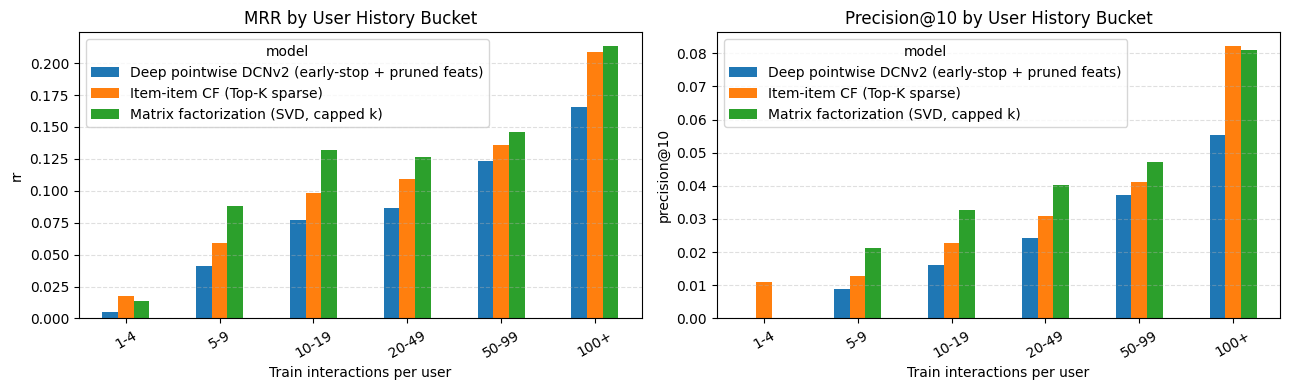

,train_bucket,model,rr,precision@10,hit@10
0,1-4,Deep pointwise DCNv2 (early-stop + pruned feats),0.005021,0.000000,0.000000
1,1-4,Item-item CF (Top-K sparse),0.017962,0.011111,0.111111
2,1-4,"Matrix factorization (SVD, capped k)",0.013850,0.000000,0.000000
3,5-9,Deep pointwise DCNv2 (early-stop + pruned feats),0.041301,0.009032,0.077419
4,5-9,Item-item CF (Top-K sparse),0.058943,0.012903,0.116129
5,5-9,"Matrix factorization (SVD, capped k)",0.088244,0.021290,0.200000
6,10-19,Deep pointwise DCNv2 (early-stop + pruned feats),0.077385,0.016086,0.149590
7,10-19,Item-item CF (Top-K sparse),0.098189,0.022643,0.194672
8,10-19,"Matrix factorization (SVD, capped k)",0.132290,0.032787,0.272541
9,20-49,Deep pointwise DCNv2 (early-stop + pruned feats),0.086194,0.024297,0.204724


In [16]:
# User-history bucket analysis: neural models often struggle more on low-history users.
bucket_edges = [0, 5, 10, 20, 50, 100, 1_000_000]
bucket_labels = ["1-4", "5-9", "10-19", "20-49", "50-99", "100+"]

model_details["train_bucket"] = pd.cut(
    model_details["train_count"],
    bins=bucket_edges,
    labels=bucket_labels,
    right=False,
)

bucket_perf = (
    model_details
    .groupby(["train_bucket", "model"])[["rr", "precision@10", "hit@10"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in [
    (axes[0], "rr", "MRR by User History Bucket"),
    (axes[1], "precision@10", "Precision@10 by User History Bucket"),
]:
    pivot = bucket_perf.pivot(index="train_bucket", columns="model", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=30)
    ax.set_title(title)
    ax.set_xlabel("Train interactions per user")
    ax.set_ylabel(metric)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

bucket_perf


In [17]:
# Qualitative examples: compare top recommendations and heldout positives for a few users.
item_id_to_title = movies_raw.set_index("item_id")["title"].to_dict()
idx_to_item_id = {idx: item_id for item_id, idx in item_to_idx.items()}


def topk_for_user(score_fn, u, k=10):
    seen = train_user_items.get(u, set())
    scores = score_fn(u).astype(np.float64, copy=True)
    if seen:
        scores[list(seen)] = -np.inf
    ranked = np.argsort(-scores)
    return ranked[:k]


def idx_items_to_titles(item_indices):
    titles = []
    for idx in item_indices:
        raw_id = idx_to_item_id.get(int(idx))
        title = item_id_to_title.get(raw_id, f"item_{raw_id}")
        titles.append(title)
    return titles

candidate_users = [
    u for u in eval_users
    if len(train_user_items.get(u, set())) >= 20 and len(eval_user_items.get(u, set())) >= 2
]
sample_users = candidate_users[:3]

example_rows = []
model_fns = [
    ("ItemCF", itemcf_score_fn),
    ("MF", lambda u: mf_scores[u]),
    ("Deep", deep_scores_for_user),
]

for u in sample_users:
    heldout_titles = idx_items_to_titles(sorted(eval_user_items[u]))
    for model_name, fn in model_fns:
        rec_idx = topk_for_user(fn, u, k=10)
        hit_idx = [i for i in rec_idx if i in eval_user_items[u]]
        example_rows.append({
            "user_index": int(u),
            "model": model_name,
            "train_count": int(len(train_user_items[u])),
            "eval_count": int(len(eval_user_items[u])),
            "top10_hits": int(len(hit_idx)),
            "heldout_examples": " | ".join(heldout_titles[:5]),
            "top5_recommendations": " | ".join(idx_items_to_titles(rec_idx[:5])),
        })

pd.DataFrame(example_rows)


,user_index,model,train_count,eval_count,top10_hits,heldout_examples,top5_recommendations
0,0,ItemCF,40,5,0,"Pocahontas (1995) | Hunchback of Notre Dame, T...",Raiders of the Lost Ark (1981) | Star Wars: Ep...
1,0,MF,40,5,0,"Pocahontas (1995) | Hunchback of Notre Dame, T...","Shawshank Redemption, The (1994) | Lion King, ..."
2,0,Deep,40,5,0,"Pocahontas (1995) | Hunchback of Notre Dame, T...","Casablanca (1942) | Graduate, The (1967) | God..."
3,1,ItemCF,65,8,0,Maverick (1994) | Mission: Impossible (1996) |...,Fargo (1996) | Schindler's List (1993) | Star ...
4,1,MF,65,8,0,Maverick (1994) | Mission: Impossible (1996) |...,Schindler's List (1993) | Good Will Hunting (1...
5,1,Deep,65,8,0,Maverick (1994) | Mission: Impossible (1996) |...,Citizen Kane (1941) | Casablanca (1942) | Rear...
6,2,ItemCF,33,4,0,"Happy Gilmore (1996) | Little Mermaid, The (19...","Die Hard (1988) | Terminator, The (1984) | Bac..."
7,2,MF,33,4,0,"Happy Gilmore (1996) | Little Mermaid, The (19...",Braveheart (1995) | Star Wars: Episode I - The...
8,2,Deep,33,4,0,"Happy Gilmore (1996) | Little Mermaid, The (19...",Terminator 2: Judgment Day (1991) | Air Force ...


### How To Interpret The Diagnostics

- If deep model has lower `hit@10` and worse `best_rank`, it is missing the first relevant item more often.
- If deep model underperforms most in low-history buckets, sparse user history is a major bottleneck.
- If recommendation popularity is very high, the model may be overfitting to popular items instead of personalization.


In [ ]:
ax = results[["MRR", "Precision@10"]].plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title(f"Offline ranking metrics on {DATASET_NAME}")
ax.set_ylabel("Metric value")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
